## Librerias

In [1]:
try:
    import pandas as pd
except ImportError:
    print("Pandas not installed")
    %pip install pandas --user

try:
    import matplotlib.pyplot as plt
except ImportError:
    print("Matplotlib not installed")
    %pip install matplotlib --user

import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Lectura de datos

- [Dataset Qatar 2022: https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data](https://www.kaggle.com/datasets/shrikrishnaparab/fifa-world-cup-2022-qatar-match-data)

In [3]:
archivo = "https://raw.githubusercontent.com/IgnacioPardo/Tecnologias_Exponenciales_2025/refs/heads/main/qatar.csv"

# Leer datos del archivo
mundial : pd.DataFrame = pd.read_csv(archivo)
mundial

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
0,1,Sun,20-Nov-22,17:00,Al Bayt Stadium,Daniele Orsato,Group A,QATAR,ECUADOR,67372,...,0,1,6,5,0,0,52,72,256,279
1,2,Mon,21-Nov-22,14:00,Khalifa International Stadium,Raphael Claus,Group B,ENGLAND,IRAN,45334,...,0,1,8,13,0,0,63,72,139,416
2,3,Mon,21-Nov-22,17:00,Al Thumama Stadium,Wilton Sampaio,Group A,SENEGAL,NETHERLANDS,41721,...,0,0,9,15,0,0,63,73,263,251
3,4,Mon,21-Nov-22,20:00,Ahmed bin Ali Stadium,Abdulrahman Ibrahim Al Jassim,Group B,UNITED STATES,WALES,43418,...,0,1,7,7,0,0,81,72,242,292
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,Sat,10-Dec-22,20:00,Al Bayt Stadium,Wilton Sampaio,Quarter-final,ENGLAND,FRANCE,68895,...,1,0,9,15,0,0,49,54,193,308
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
61,62,Wed,14-Dec-22,20:00,Al Bayt Stadium,Cesar Ramos,Semi-Final,FRANCE,MOROCCO,68294,...,0,0,13,14,0,0,72,47,328,218
62,63,Sat,17-Dec-22,16:00,Khalifa International Stadium,Abdulrahman Ibrahim Al Jassim,Play-off for third place,CROATIA,MOROCCO,44137,...,0,0,7,14,0,0,75,72,288,277


In [4]:
# Cuantos partidos se jugaron?
# Completar
mundial['match_no'].count()


np.int64(64)

In [5]:
# Que datos tiene el dataset? (Pista: usar .info(), .describe(), .columns, .head())
# Checkear columnas
# Completar
mundial.columns




Index(['match_no', 'day_of_week', 'date', 'hour', 'venue', 'referee', 'group',
       '1', '2', 'attendance', '1_xg', '2_xg', '1_poss', '2_poss', '1_goals',
       '2_goals', 'score', '1_attempts', '2_attempts', '1_conceded',
       '2_conceded', '1_goal_inside_penalty_area',
       '2_goal_inside_penalty_area', '1_goal_outside_penalty_area',
       '2_goal_outside_penalty_area', '1_ontarget', '2_ontarget',
       '1_offtarget', '2_offtarget', '1_attempts_inside_penalty_area',
       '2_attempts_inside_penalty_area', '1_attempts_outside_penalty_area',
       '2_attempts_outside_penalty_area', '1_yellow_cards', '2_yellow_cards',
       '1_red_cards', '2_red_cards', 'faul_against_1', 'faul_against_2',
       '1_offsides', '2_offsides', '1_passes', '2_passes',
       '1_passes_compeletd', '2_passes_compeletd', '1_corners', '2_corners',
       '1_free_kicks', '2_free_kicks', '1_panelties_scored',
       '2_panelties_scored', '1_goal_prevented', '2_goal_prevented',
       '1_own_goal', '2_o

## Analisis

### Primera Parte

In [6]:
# Cuantas selecciones participaron?
# Completar
mundial["1"].nunique()


32

In [7]:
# Cuantas fases tiene el mundial?
# Completar
mundial["group"].nunique()

13

In [8]:
# Cual fue la "attendance" promedio por partido?
# Completar
mundial["attendance"].mean()

np.float64(53191.4375)

In [9]:
# Cual fue el partido con mas diferencia de goles?
# Completar
diferencia = abs(mundial["1_goals"] - mundial["2_goals"]) # ABS seria el modulo, osea el valor sin el signo
diferencia.max()
mundial.loc[diferencia.idxmax(), ["1", "2", "score"]] # .loc me da la fila del indice que le diga yo, y diferencia.idxmax me da el indice de la fila en la que diferencia tenga el numero mayor, y despues le pido solo la info de las columnas que quiera yo

,10
1,SPAIN
2,COSTA RICA
score,"7,0"


In [10]:
# Cual es la selección que mas penales metió?
# Completar
penalesConvertidos1 = mundial.groupby("1")["1_panelties_scored"].sum()
penalesConvertidos2 = mundial.groupby("2")["2_panelties_scored"].sum()
totalPenalesConvertidos = penalesConvertidos1 + penalesConvertidos2 # TE LOS VA A ALINEAR POR NOMBRE CON LO CUAL VA A SUMAR LOS DE ARGENTINA CUANDO ESTABA EN UNO CON LOS DE ARGENTINA CUANDO ESTABA EN 2

totalPenalesConvertidos.idxmax()



'ARGENTINA'

In [11]:
# Cual es la selección que mas penales le hicieron?
# Completar
penalesEnContra1 = mundial.groupby("1")["2_panelties_scored"].sum()
penalesEnContra2 = mundial.groupby("2")["1_panelties_scored"].sum()
totalPenalesEnContra = penalesEnContra1 + penalesEnContra2

totalPenalesEnContra.idxmax()
mundial.groupby

<bound method DataFrame.groupby of     match_no day_of_week       date   hour                          venue  \
0          1         Sun  20-Nov-22  17:00                Al Bayt Stadium   
1          2         Mon  21-Nov-22  14:00  Khalifa International Stadium   
2          3         Mon  21-Nov-22  17:00             Al Thumama Stadium   
3          4         Mon  21-Nov-22  20:00          Ahmed bin Ali Stadium   
4          5         Tue  22-Nov-22  11:00          Lusail Iconic Stadium   
..       ...         ...        ...    ...                            ...   
59        60         Sat  10-Dec-22  20:00                Al Bayt Stadium   
60        61         Tue  13-Dec-22  20:00          Lusail Iconic Stadium   
61        62         Wed  14-Dec-22  20:00                Al Bayt Stadium   
62        63         Sat  17-Dec-22  16:00  Khalifa International Stadium   
63        64         Sun  18-Dec-22  16:00          Lusail Iconic Stadium   

                          referee                     group              1  \
0                  Daniele Orsato                   Group A          QATAR   
1                   Raphael Claus                   Group B        ENGLAND   
2                  Wilton Sampaio                   Group A        SENEGAL   
3   Abdulrahman Ibrahim Al Jassim                   Group B  UNITED STATES   
4                   Slavko Vincic                   Group C      ARGENTINA   
..                            ...                       ...            ...   
59                 Wilton Sampaio             Quarter-final        ENGLAND   
60                 Daniele Orsato                Semi-Final      ARGENTINA   
61                    Cesar Ramos                Semi-Final         FRANCE   
62  Abdulrahman Ibrahim Al Jassim  Play-off for third place        CROATIA   
63               Szymon Marciniak                     Final      ARGENTINA   

               2  attendance  ...  1_panelties_scored  2_panelties_scored  \
0        ECUADOR       67372  ...                   0                   1   
1           IRAN       45334  ...                   0                   1   
2    NETHERLANDS       41721  ...                   0                   0   
3          WALES       43418  ...                   0                   1   
4   SAUDI ARABIA       88012  ...                   1                   0   
..           ...         ...  ...                 ...                 ...   
59        FRANCE       68895  ...                   1                   0   
60       CROATIA       88966  ...                   1                   0   
61       MOROCCO       68294  ...                   0                   0   
62       MOROCCO       44137  ...                   0                   0   
63        FRANCE       88966  ...                   1                   2   

    1_goal_prevented  2_goal_prevented  1_own_goal  2_own_goal  \
0                  6                 5           0           0   
1                  8                13           0           0   
2                  9                15           0           0   
3                  7                 7           0           0   
4                  4                14           0           0   
..               ...               ...         ...         ...   
59                 9                15           0           0   
60                12                10           0           0   
61                13                14           0           0   
62                 7                14           0           0   
63                11                21           0           0   

   1_forced_turnovers  2_forced_turnovers  1_defensive_pressure_applied  \
0                  52                  72                           256   
1                  63                  72                           139   
2                  63                  73                           263   
3                  81                  72                           242   
4         

### Segunda Parte

In [12]:
equipo : str = "ARGENTINA"

In [13]:
# Seleccionar todos los partidos que jugo el equipo de "local"
# Completar

filtroLocal : pd.Series = mundial["1"] == equipo
mundial[filtroLocal]

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [14]:
# Seleccionar todos los partidos que jugo el equipo de "visitante"
# Completar

filtroVisitante : pd.Series = mundial["2"] == equipo
mundial[filtroVisitante]

,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323


In [15]:
# Seleccionar todos los partidos que jugo el equipo (de "local" o "visitante")
# Completar

partidos : pd.DataFrame = mundial[(mundial["1"] == equipo) | (mundial["2"] == equipo)]
partidos


,match_no,day_of_week,date,hour,venue,referee,group,1,2,attendance,...,1_panelties_scored,2_panelties_scored,1_goal_prevented,2_goal_prevented,1_own_goal,2_own_goal,1_forced_turnovers,2_forced_turnovers,1_defensive_pressure_applied,2_defensive_pressure_applied
4,5,Tue,22-Nov-22,11:00,Lusail Iconic Stadium,Slavko Vincic,Group C,ARGENTINA,SAUDI ARABIA,88012,...,1,0,4,14,0,0,65,80,163,361
23,24,Sat,26-Nov-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Group C,ARGENTINA,MEXICO,88966,...,0,0,4,5,0,0,63,79,220,327
38,39,Wed,30-Nov-22,20:00,Lusail Iconic Stadium,Michael Oliver,Group C,POLAND,ARGENTINA,84985,...,0,0,25,4,0,0,67,48,438,141
49,50,Sat,3-Dec-22,20:00,Ahmed bin Ali Stadium,Szymon Marciniak,Round of 16,ARGENTINA,AUSTRALIA,45032,...,0,0,5,14,1,0,67,73,240,453
57,58,Fri,9-Dec-22,20:00,Lusail Iconic Stadium,Antonio Mateu Lahoz,Quarter-final,NETHERLANDS,ARGENTINA,88235,...,0,1,15,5,0,0,91,79,401,323
60,61,Tue,13-Dec-22,20:00,Lusail Iconic Stadium,Daniele Orsato,Semi-Final,ARGENTINA,CROATIA,88966,...,1,0,12,10,0,0,85,63,321,260
63,64,Sun,18-Dec-22,16:00,Lusail Iconic Stadium,Szymon Marciniak,Final,ARGENTINA,FRANCE,88966,...,1,2,11,21,0,0,87,104,280,409


In [16]:
mundial[filtroLocal]["1_goals"].sum()


np.int64(11)

In [17]:
# Cuantos goles hizo el equipo en total (obtener los goles metidos de local y sumarlos con los goles metidos de visitante)
# Completar
golesLocal = mundial[filtroLocal]["1_goals"].sum() # ACORDATE FILTROLOCAL ES LO MISMO QUE PONER mundial["1"] == equipo
golesVisitante = mundial[filtroVisitante]["2_goals"].sum()
goles : int = golesLocal + golesVisitante
goles


np.int64(15)

In [18]:
# Cuantos goles hizo el equipo en promedio
# Completar
partidosDeLocal = mundial.loc[mundial["1"] == equipo, "1_goals"].count() # CUENTO LA CANTIDAD DE PARTIDOS DE LOCAL
partidosdeVisitante = mundial.loc[mundial["2"] == equipo, "2_goals"].count() # LO MISMO CON LOS PARTIDOS DE VISITANTE
partidosTotal = partidosDeLocal + partidosdeVisitante # SUMO
golesPromedio = goles/partidosTotal # DIVIDO LOS GOLES POR EL TOTAL DE PARTIDOS
golesPromedio


np.float64(2.142857142857143)

In [19]:
# Cuantos partidos gano el equipo
# Completar
partidosGanadosLocal = mundial.loc[(filtroLocal) & (mundial["1_goals"] > mundial["2_goals"]), "1_goals"].count()
partidosGanadosVisitante = mundial.loc[(filtroVisitante) & (mundial["2_goals"] > mundial["1_goals"]), "1_goals"].count()

ganados : int = partidosGanadosLocal + partidosGanadosVisitante
ganados # SIN CONTAR LOS GANADOS POR PENALES


np.int64(4)

Text(0, 0.5, 'Goles')

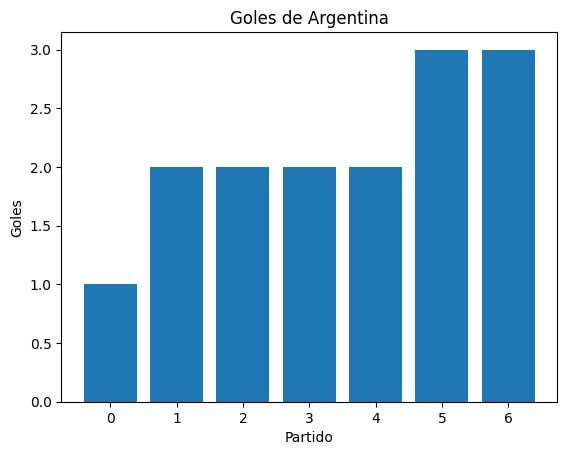

In [26]:
# Graficar los goles hechos por el equipo en cada partido

fig, ax = plt.subplots()

goles = [] # CREO UNA LISTA
for i in range(mundial.shape[0]):
    if mundial.iloc[i]['1'] == equipo:
        goles.append(mundial.iloc[i]['1_goals']) # SUMO A LA LISTA LOS GOLES HECHOS EN PARTIDO CUANDO ARGENTINA 1
    elif mundial.iloc[i]['2'] == equipo:
        goles.append(mundial.iloc[i]['2_goals']) # SUMO A LA LISTA LOS GOLES HECHOS EN PARTIDO CUANDO ARGENTINA 2

ax.bar(range(len(goles)), goles) # CUANTO MIDE X Y QUE VALORES TIENE Y EN QUE POSICIONES
ax.set_title("Goles de Argentina")
ax.set_xlabel("Partido")
ax.set_ylabel("Goles")


### Tercera Parte

In [ ]:
# Contar cuantos goles hizo cada equipo en total en el mundial
# Completar

golesEquiposEstandodeLocal = mundial.groupby("1") ["1_goals"].sum()
golesEquiposEstandodeVisitante = mundial.groupby("2") ["2_goals"].sum()
golesEquipos = golesEquiposEstandodeLocal + golesEquiposEstandodeVisitante
golesEquipos



,0
1,
ARGENTINA,15
AUSTRALIA,4
BELGIUM,1
BRAZIL,8
CAMEROON,4
CANADA,2
COSTA RICA,3
CROATIA,8
DENMARK,1


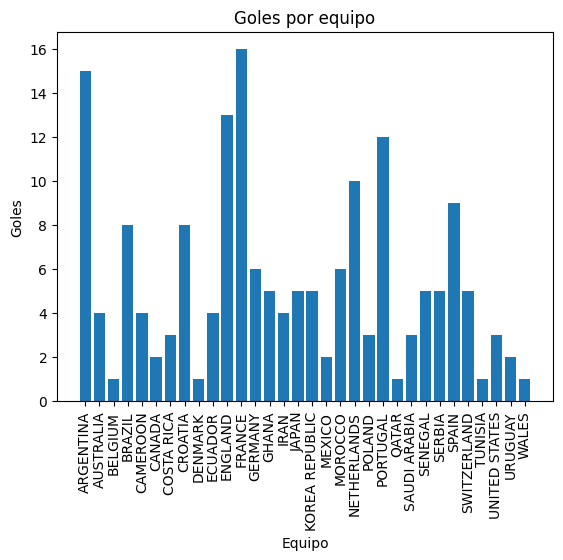

In [56]:
# Graficar los goles por equipo en todo el mundial

goles1 = mundial.groupby('1')['1_goals'].sum()
goles2 = mundial.groupby('2')['2_goals'].sum()
goles_totales = goles1 + goles2
fig, ax = plt.subplots()
ax.bar(goles_totales.index, goles_totales.values)
ax.set_title('Goles por equipo')
ax.set_xlabel('Equipo')
ax.set_ylabel('Goles')
plt.xticks(rotation=90) # PARA QUE LOS NOMBRES ESTEN VERTICALES
plt.show()


In [40]:
# Cual es el equipo que hizo mas goles en el mundial?
# Completar
golesDe1 = mundial.groupby("1")["1_goals"].sum()
golesDe2 = mundial.groupby("2")["2_goals"].sum()
# ACA TENGO 2 TABLAS
sumaDeGolesDeEquipos = golesDe1 + golesDe2 # LAS SUMO Y SE SUMAN LOS INDICES QUE SENA IGUALES
sumaDeGolesDeEquipos.idxmax() # COMO EL INDICE ES UNA PALABRA, ME DEVUELVE LA QUE TENGA GOLES MAXIMOS

'FRANCE'

In [ ]:
# Por cada partido, cual fue la diferencia de goles?
# Completar
abs(mundial["1_goals"] - mundial["2_goals"])


,0
0,2
1,4
2,2
3,0
4,1
...,...
59,1
60,3
61,2
62,1


In [43]:
# Por cada partido, cual fue el equipo que gano?
# Completar
for i in range(mundial.shape[0]):
    if mundial.iloc[i]['1_goals'] > mundial.iloc[i]['2_goals']:
        print(mundial.iloc[i]['1'])
    elif mundial.iloc[i]['1_goals'] < mundial.iloc[i]['2_goals']:
        print(mundial.iloc[i]['2'])
    else:
        print("Empate")

ECUADOR
ENGLAND
NETHERLANDS
Empate
SAUDI ARABIA
Empate
Empate
FRANCE
Empate
JAPAN
SPAIN
BELGIUM
SWITZERLAND
Empate
PORTUGAL
BRAZIL
IRAN
SENEGAL
Empate
Empate
AUSTRALIA
POLAND
FRANCE
ARGENTINA
COSTA RICA
MOROCCO
CROATIA
Empate
Empate
GHANA
BRAZIL
PORTUGAL
NETHERLANDS
SENEGAL
ENGLAND
UNITED STATES
AUSTRALIA
TUNISIA
ARGENTINA
MEXICO
Empate
MOROCCO
JAPAN
GERMANY
URUGUAY
KOREA REPUBLIC
SWITZERLAND
CAMEROON
NETHERLANDS
ARGENTINA
FRANCE
ENGLAND
Empate
BRAZIL
Empate
PORTUGAL
Empate
Empate
MOROCCO
FRANCE
ARGENTINA
FRANCE
CROATIA
Empate


In [46]:
# En cada fase del mundial, cual fue el equipo que hizo mas goles?
# Completar
goles_1 = mundial[['group', '1', '1_goals']].rename(columns={'1': 'equipo', '1_goals': 'goles'})
goles_2 = mundial[['group', '2', '2_goals']].rename(columns={'2': 'equipo', '2_goals': 'goles'})

pd.concat([goles_1, goles_2]).groupby(['group', 'equipo'])['goles'].sum().groupby('group').idxmax()

,goles
group,
Final,"(Final, ARGENTINA)"
Group A,"(Group A, NETHERLANDS)"
Group B,"(Group B, ENGLAND)"
Group C,"(Group C, ARGENTINA)"
Group D,"(Group D, FRANCE)"
Group E,"(Group E, SPAIN)"
Group F,"(Group F, CROATIA)"
Group G,"(Group G, SERBIA)"
Group H,"(Group H, PORTUGAL)"


### Tercera Parte

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Final'),
  Text(1, 0, 'Group A'),
  Text(2, 0, 'Group B'),
  Text(3, 0, 'Group C'),
  Text(4, 0, 'Group D'),
  Text(5, 0, 'Group E'),
  Text(6, 0, 'Group F'),
  Text(7, 0, 'Group G'),
  Text(8, 0, 'Group H'),
  Text(9, 0, 'Play-off for third place'),
  Text(10, 0, 'Quarter-final'),
  Text(11, 0, 'Round of 16'),
  Text(12, 0, 'Semi-Final')])

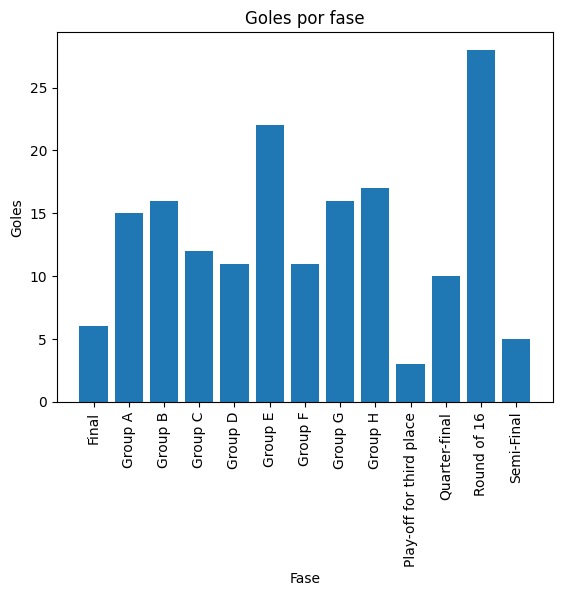

In [62]:
# Armar un gráfico a partir de algun nuevo análisis que se te ocurra
# Completar
golesPorFase = mundial.groupby("group") [["1_goals", "2_goals"]].sum()
golesPorFase["total"] = golesPorFase["1_goals"] + golesPorFase["2_goals"]

fig, ax = plt.subplots()
ax.bar (golesPorFase.index, golesPorFase["total"].values)
ax.set_title("Goles por fase")
ax.set_xlabel("Fase")
ax.set_ylabel("Goles")
plt.xticks(rotation=90)
